In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Exploratory Data Analysis
- Dados disponiveis no [kaggle](https://www.kaggle.com/code/salma20/kdd-data-analysis/input?select=KDDTest-21.arff)

#### Dicionario dos dados

1. Basic Features (Conexão TCP/IP)
São atributos extraídos do cabeçalho do pacote.

- duration: Tempo de duração da conexão (em segundos).

- protocol_type: O protocolo (TCP, UDP, ICMP).

- service: O serviço de destino (HTTP, Telnet, FTP, etc.).

- src_bytes / dst_bytes: Quantidade de dados enviados (origem->destino) e recebidos (destino->origem).

- flag: O estado da conexão (veja detalhe abaixo, é muito importante).

- land: 1 se a conexão for da mesma porta/IP para a mesma porta/IP (ataque Land).

2. Content Features (Conteúdo/Payload)
Sugerem comportamentos suspeitos dentro do payload do pacote (ex: tentativas de root).

- hot: Contador de indicadores "quentes" (ex: entrar em diretórios de sistema).

- num_failed_logins: Quantas vezes errou a senha.

- logged_in: 1 se logou com sucesso, 0 se não.

- root_shell: 1 se obteve shell de root.

- su_attempted: 1 se tentou comando "su root".

- is_guest_login: 1 se for login de convidado.

3. Time-based Traffic Features (Janela de 2 segundos)
Analisam o volume de tráfego nos últimos 2 segundos (ótimo para detectar DoS e Probing).

- count: Número de conexões para o mesmo host de destino nos últimos 2s.

- srv_count: Número de conexões para o mesmo serviço (porta) nos últimos 2s.

- serror_rate / rerror_rate: Porcentagem de conexões que tiveram erro de SYN (serror) ou REJ (rerror). Alto índice aqui indica varredura de portas ou SYN Flood.

4. Host-based Traffic Features (Histórico)
Similares às anteriores, mas olham para um histórico de conexões (últimas 100 conexões) ao invés de tempo. Ajudam a detectar ataques lentos que tentam fugir da janela de 2 segundos.

- O atributo "FLAG" indica como a conexão terminou. As siglas significam:

> SF: Normal (Conexão estabelecida e terminada corretamente - Start/Finish).
> 
> S0: Tentativa de conexão vista, mas sem resposta (típico de varredura).
>
> REJ: Conexão rejeitada (RST).
>
> RSTO / RSTR: Conexão resetada pelo originador ou pelo respondente.

Stolfo, S. J., Fan, W., Lee, W., Prodromidis, A., & Chan, P. K. (2000). Cost-based modeling for fraud and intrusion detection: Results from the JAM project.

In [2]:
# Definição dos nomes das colunas conforme o cabeçalho do KDDTest-21
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class','difficulty'
]

# Carregando o dataset
# Ajuste o caminho 'KDDTest-21.txt' para o local do seu arquivo
df = pd.read_csv('../data/KDDTest-21.txt', sep=',', names=col_names, index_col=False)

# Verificação
print(f"Dataset: {df.shape}")
df.head()

Dataset: (11850, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,guess_passwd,2
1,0,udp,private,SF,44,0,0,0,0,0,...,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,snmpguess,12
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,processtable,18
3,0,udp,private,SF,53,55,0,0,0,0,...,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal,17
4,0,tcp,private,SH,0,0,0,0,0,0,...,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,nmap,17


In [3]:
df_plot = df.copy()

In [7]:

# Se a classe for 'normal' é 0, qualquer outra coisa (ataque) é 1
df_plot['is_attack'] = df_plot['class'].apply(lambda x: 0 if x == 'normal' else 1)

# Filtrar apenas colunas numericas para a correlaçao
df_plot_numeric = df_plot.select_dtypes(include=[np.number])

# Calcular a correlação
corr_matrix = df_plot_numeric.corr()

# filtrnado apenas as correlacoes acima de 0.6
corr_matrix = corr_matrix[((corr_matrix >= 0.6) | (corr_matrix <= -0.6)) & (corr_matrix != 1.0)]

# tirando as colunas que nao foram filtradas
corr_matrix = corr_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

# Plotar (Heatmap)
fig_corr = px.imshow(corr_matrix, 
                     text_auto=False, 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     title="Matriz de Correlação (Features Numéricas)")
fig_corr.show()

In [8]:

# log_x e log_y ajudam a visualizar melhor dados de rede que variam muito
fig_scatter = px.scatter(df, 
                         x='src_bytes', 
                         y='dst_bytes', 
                         color='class', 
                         log_x=True, 
                         log_y=True,
                         title="Distribuição de trafego: Origem vs Destino (Escala Log)",
                         hover_data=['service', 'flag']) 
fig_scatter.show()

In [9]:

fig_bar = px.histogram(df, 
                       x='class', 
                       color='class', 
                       title="Distribuição das Classes (Quantidade de Registros)")
fig_bar.update_layout(showlegend=False)
fig_bar.show()

_Obs_: as classes estão desbalanceadas. Tomar cuidado com vies no treino do modelo.

## 2. Modelagem


In [11]:
# --- 1. PREPARAÇÃO DOS DADOS (ENCODING) ---

# Vamos criar uma cópia para não alterar o dataframe original se precisarmos depois
df_train = df.copy()

# Remover a coluna auxiliar 'is_attack' se ela ainda existir do passo anterior
if 'is_attack' in df_train.columns:
    df_train.drop('is_attack', axis=1, inplace=True)

# Encoding das variáveis categóricas (Textos -> Números)
# Usamos LabelEncoder pois modelos de árvore lidam bem com isso
categorical_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in categorical_cols:
    df_train[col] = le.fit_transform(df_train[col])


In [12]:

# --- 2. DEFINIÇÃO DO ALVO (TARGET) ---

# Para detecção de intrusão, vamos assumir: Normal = 0, Ataque = 1
# Se 'class' for 'normal', vira 0. Qualquer outra coisa vira 1.
y = df_train['class'].apply(lambda x: 0 if x == 'normal' else 1)
X = df_train.drop('class', axis=1)

In [13]:

# --- 3. CÁLCULO DO FATOR DE DESBALANCEAMENTO ---

# Contagem
count_neg = (y == 0).sum() # Normais
count_pos = (y == 1).sum() # Ataques

# Fórmula recomendada pelo XGBoost: sum(negative instances) / sum(positive instances)
# Isso diz ao modelo: "Um erro na classe minoritária custa X vezes mais que na majoritária"
scale_pos_weight = count_neg / count_pos

print(f"Registros Normais (0): {count_neg}")
print(f"Registros de Ataque (1): {count_pos}")
print(f"Fator de peso calculado (scale_pos_weight): {scale_pos_weight:.2f}")


Registros Normais (0): 2152
Registros de Ataque (1): 9698
Fator de peso calculado (scale_pos_weight): 0.22


In [14]:

# --- 4. DIVISÃO E TREINO (STRATIFIED) ---

# stratify=y garante que a proporção de ataques seja a mesma no treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Instanciando o XGBoost com o peso de correção
model = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight, # A MÁGICA DO BALANCEAMENTO ACONTECE AQUI
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print("\nTreinando o modelo XGBoost...")
model.fit(X_train, y_train)



Treinando o modelo XGBoost...


c:\Users\BRCoelhoAn2\Trabalho-Final-IDS\venv\Lib\site-packages\xgboost\training.py:199: UserWarning:

[23:15:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [15]:

# --- 5. AVALIAÇÃO ---

y_pred = model.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataque']))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))


--- Relatório de Classificação ---
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98       646
      Ataque       1.00      0.99      1.00      2909

    accuracy                           0.99      3555
   macro avg       0.98      0.99      0.99      3555
weighted avg       0.99      0.99      0.99      3555


--- Matriz de Confusão ---
[[ 635   11]
 [  18 2891]]


- Recall da classe "Ataque": 18 falsos negativos (deixar um hacker entrar achando que é normal) é um ótimo resultado.

- F1-Score: acima de 0.98 para ambas as classes.

## 3. Explicabilidade com SHAP

Gerando Summary Plot...


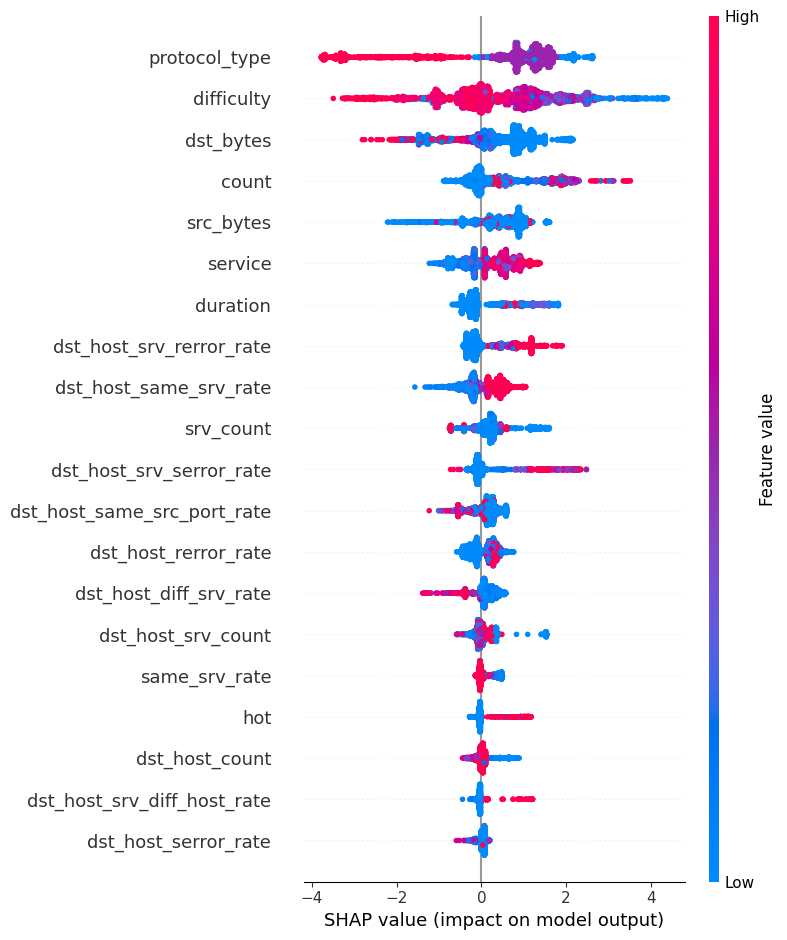

Explicando o registro de teste número: 0


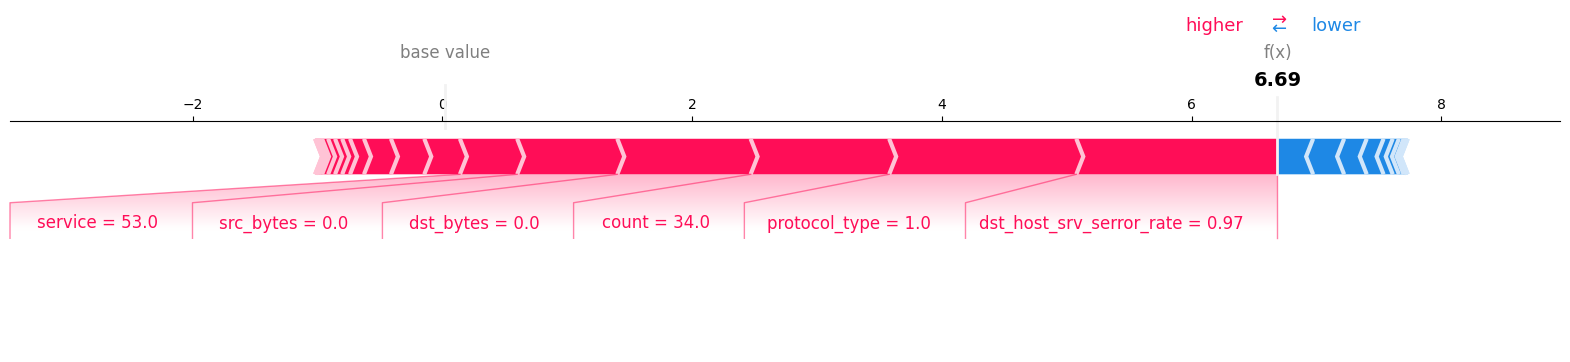

Arquivo 'shap_explicacao_local.html' salvo! Abra para comparar com o LIME.


In [20]:
import shap

# 1. Inicializar o JS para visualização (necessário se estiver usando Jupyter/Notebook)
shap.initjs()

# 2. Criar o Explainer específico para Árvores (muito rápido com XGBoost)
# Passamos o modelo treinado
explainer = shap.TreeExplainer(model)

# 3. Calcular os valores SHAP para o conjunto de teste
# (Usamos apenas uma amostra de teste para não travar a memória se o dataset for gigante, 
# mas com 3500 linhas pode usar tudo)
shap_values = explainer.shap_values(X_test)

# --- GRÁFICO 1: VISÃO GLOBAL (Summary Plot) ---
# Esse gráfico mostra quais features mais impactam a decisão.
# Pontos vermelhos = valor alto da feature. Pontos azuis = valor baixo.
# Se esticar para a direita = contribui para ser Ataque (1). Esquerda = Normal (0).
print("Gerando Summary Plot...")
shap.summary_plot(shap_values, X_test, plot_type="dot")

# --- GRÁFICO 2: VISÃO LOCAL (Force Plot de um caso de Falso Negativo) ---
# Vamos tentar achar um caso onde o modelo errou (era ataque mas ele disse normal) ou acertou um ataque difícil.
# Vamos pegar o primeiro caso do teste que o modelo classificou como Ataque.

# Pega o índice do primeiro registro que o modelo previu como ataque
import numpy as np
coords_ataque = np.where(y_pred == 1)[0][0]

print(f"Explicando o registro de teste número: {coords_ataque}")

shap.force_plot(explainer.expected_value, 
                shap_values[coords_ataque,:], 
                X_test.iloc[coords_ataque,:], 
                matplotlib=True) 

# 1. Recriar o plot para a MESMA instância que usamos no LIME
# Lembra da variável 'coords_ataque' que definimos antes? Vamos usar ela.
p = shap.force_plot(
    explainer.expected_value, 
    shap_values[coords_ataque,:], 
    X_test.iloc[coords_ataque,:]
)

# 2. Salvar em HTML
shap.save_html("../output/shap_explicacao_local.html", p)

print("Arquivo 'shap_explicacao_local.html' salvo! Abra para comparar com o LIME.")

## 4. Explicabilidade com LIME

In [19]:
import lime
import lime.lime_tabular

# 1. Criar o Explainer do LIME
# Precisamos passar os dados de treino para ele aprender as estatísticas (média, desvio padrão)
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Normal', 'Ataque'],
    mode='classification'
)

# 2. Escolher uma instância para explicar (vamos usar a mesma do SHAP para comparar)
# Instância do teste que queremos explicar
idx_to_explain = coords_ataque # Mesmo índice usado no SHAP acima
instance = X_test.iloc[idx_to_explain]

# 3. Gerar a explicação
# num_features=10 mostra as top 10 features que pesaram na decisão
exp = explainer_lime.explain_instance(
    data_row=instance, 
    predict_fn=model.predict_proba, 
    num_features=10
)

# Salva um arquivo.html na pasta do seu projeto
exp.save_to_file('../output/lime_output.html')

print("Arquivo 'lime_output.html' salvo com sucesso.")

c:\Users\BRCoelhoAn2\Trabalho-Final-IDS\venv\Lib\site-packages\lime\discretize.py:110: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

c:\Users\BRCoelhoAn2\Trabalho-Final-IDS\venv\Lib\site-packages\lime\discretize.py:110: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`

c:\Users\BRCoelhoAn2\Trabalho-Final-IDS\venv\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

c:\Users\BRCoelhoAn2\Trabalho-

Arquivo 'lime_output.html' salvo com sucesso.
